In [39]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# o cwd do notebook é notebooks/, então todo caminho precisa sair da raiz do projeto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = RAIZ / "data"
sys.path.insert(0, str(RAIZ / "src"))

from moq import metrics, portfolio

plt.rcParams["figure.figsize"] = (10, 4)

pf = pd.read_parquet( DATA /"processed"/"portfolio_final.parquet")
p, cdi = pf["portfolio"], pf["cdi"]
R = pd.read_parquet( DATA /"processed"/"retornos_oos.parquet").reindex(p.index)
F = pd.read_parquet( DATA /"processed"/"fatores.parquet").reindex(p.index)
w = portfolio.risk_parity(R)          # pesos SEM alavancagem (somam 1); `p` é isto × k, veja a seção de cenários
print(metrics.summary(p, cdi))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
{'ret_anual': 0.07740592439858007, 'vol_anual': np.float64(0.03384123001588369), 'sharpe': np.float64(-0.5969482151608254), 'max_dd': -0.05733370389661163}


drawdown máximo: -5.73%


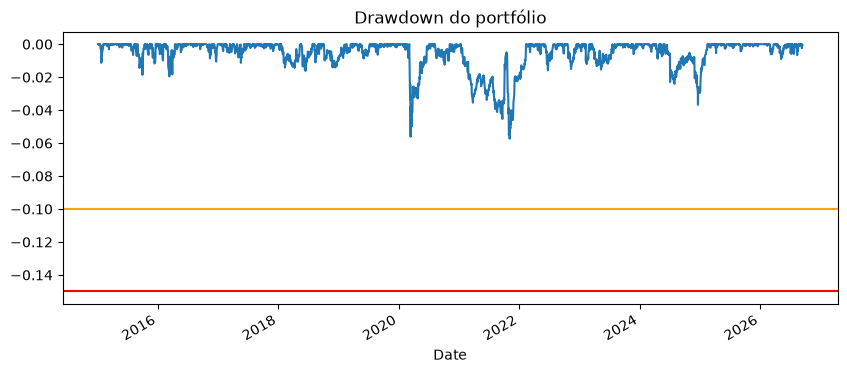

In [40]:
dd = metrics.drawdown(p)
print(f"drawdown máximo: {dd.min():.2%}")      # o portfólio nunca chega perto de −10%
dd.plot(title="Drawdown do portfólio"); plt.axhline(-0.10, color="orange"); plt.axhline(-0.15, color="red");

dias por estado: {1.0: 2912}


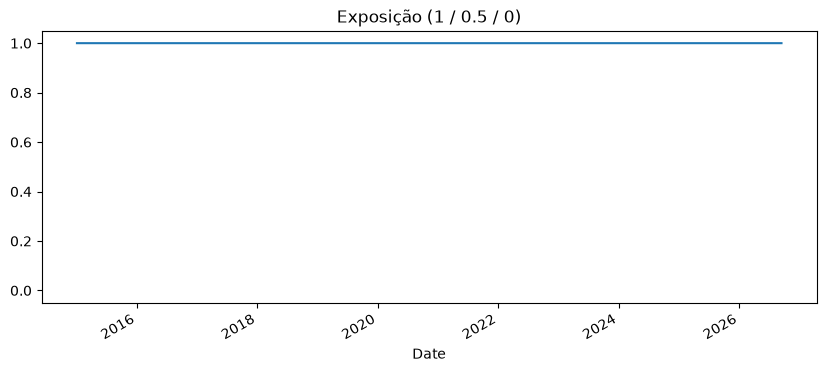

In [41]:
# Máquina de estados na mão. Duas coisas que não são óbvias no laço:
#  - o gatilho é o drawdown do portfólio SEM a regra (curva-sombra), não o de quem segue a regra;
#  - FULL só volta num novo topo dessa sombra, e a volta de um STOP não passa por HALF.
dd_ontem = dd.shift(1).fillna(0.0)     # decisão de hoje usa o drawdown até ontem
exposure = np.empty(len(p))
state = 1.0
for t, d in enumerate(dd_ontem.to_numpy()):
    if d >= -1e-12:                         state = 1.0    # novo topo → FULL
    elif d < -0.15:                         state = 0.0    # STOP
    elif d < -0.10 and state == 1.0:        state = 0.5    # HALF, só se entra vindo de FULL
    exposure[t] = state
exposure = pd.Series(exposure, index=p.index, name="exposure")
print("dias por estado:", exposure.value_counts().to_dict())   # com −10%/−15% a regra nunca dispara aqui
exposure.plot(title="Exposição (1 / 0.5 / 0)", ylim=(-0.05, 1.05));

,sem regra,com regra
ret_anual,0.077,0.077
vol_anual,0.034,0.034
sharpe,-0.597,-0.597
max_dd,-0.057,-0.057


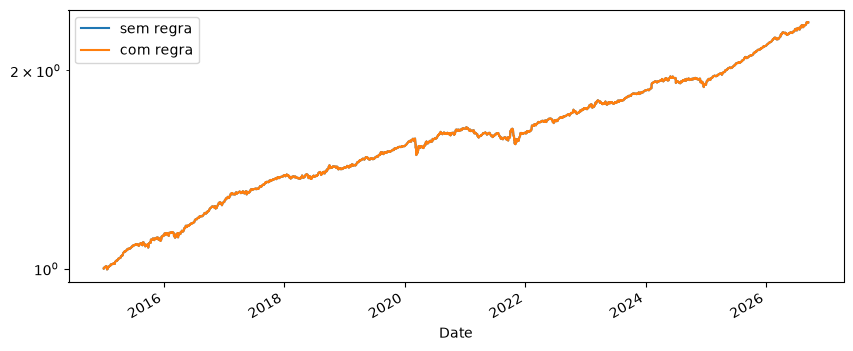

In [42]:
# Com os limiares de livro a regra é inerte neste portfólio: as duas curvas são a mesma.
p_gerido = portfolio.apply_exposure(p, exposure, cdi)
pd.DataFrame({"sem regra": (1 + p).cumprod(), "com regra": (1 + p_gerido).cumprod()}).plot(logy=True)
pd.DataFrame({"sem regra": metrics.summary(p, cdi), "com regra": metrics.summary(p_gerido, cdi)}).round(3)

dias por estado: {1.0: 2570, 0.0: 175, 0.5: 167}


,sem regra,com regra
ret_anual,0.077,0.073
vol_anual,0.034,0.029
sharpe,-0.597,-0.863
max_dd,-0.057,-0.045


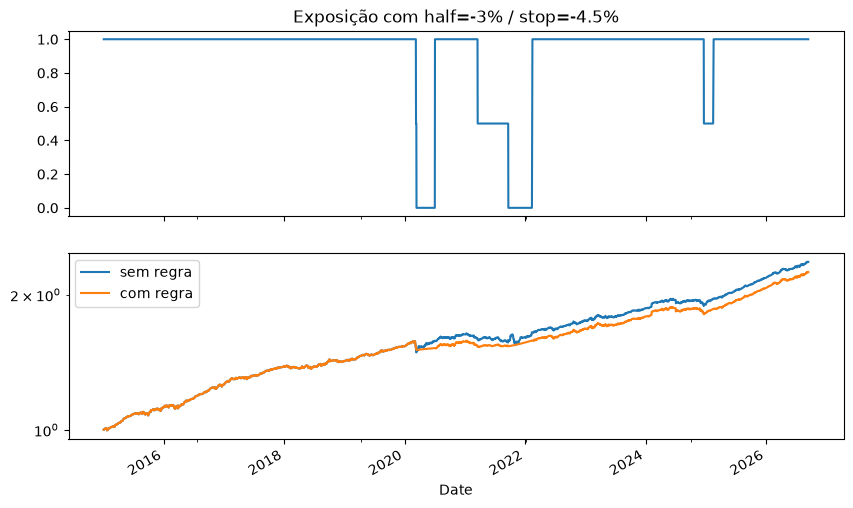

In [43]:
# Para a regra dizer alguma coisa, os limiares têm que estar na escala do drawdown deste portfólio
# (1º percentil ≈ −4%). Isto é calibragem à posteriori: leia como ilustração, não como resultado.
regra = portfolio.DrawdownRule(dd_half=-0.03, dd_stop=-0.045)
exp_cal = portfolio.drawdown_control(p, regra)
p_cal = portfolio.apply_exposure(p, exp_cal, cdi)
print("dias por estado:", exp_cal.value_counts().to_dict())
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
exp_cal.plot(ax=ax1, title=f"Exposição com half={regra.dd_half:.0%} / stop={regra.dd_stop:.1%}", ylim=(-0.05, 1.05))
pd.DataFrame({"sem regra": (1 + p).cumprod(), "com regra": (1 + p_cal).cumprod()}).plot(ax=ax2, logy=True)
pd.DataFrame({"sem regra": metrics.summary(p, cdi), "com regra": metrics.summary(p_cal, cdi)}).round(3)
# max_dd cai, mas o Sharpe também: a parada trava o prejuízo e perde o repique.
# E nada aqui cobra custo de giro — cada troca de estado é um rebalanceamento de verdade.

In [44]:

teste = pd.Series(np.concatenate([np.full(50, 0.002), np.full(60, -0.0021), np.full(20, -0.0025), np.full(200, 0.003)]),
                  index=pd.bdate_range("2020-01-01", periods=330))
esperado = portfolio.drawdown_control(teste, portfolio.DrawdownRule(-0.10, -0.15))
print("estados visitados:", sorted(esperado.unique()))
print("igual ao laço acima?", (portfolio.drawdown_control(p) == exposure).all())

estados visitados: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]
igual ao laço acima? True


       momentum  reversao     pares     carry
count  2787.000  2787.000  2787.000  2787.000
mean      0.291     0.280     0.240     0.189
std       0.190     0.165     0.231     0.242
min      -0.064     0.018    -0.009    -0.006
25%       0.126     0.148     0.057     0.000
50%       0.289     0.278     0.188     0.059
75%       0.473     0.382     0.320     0.384
max       0.718     0.886     1.005     0.881


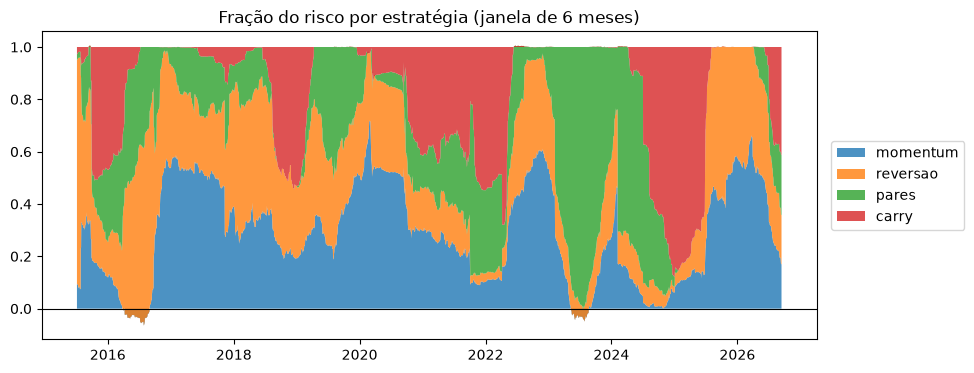

In [45]:

rc = portfolio.rolling_risk_contribution(R, w, window=126)
cum = rc.cumsum(axis=1)
fig, ax = plt.subplots()
base = np.zeros(len(rc))
for col in rc.columns:
    ax.fill_between(rc.index, base, cum[col], label=col, alpha=0.8)
    base = cum[col].to_numpy()
ax.axhline(0, color="k", lw=0.8)
ax.set_title("Fração do risco por estratégia (janela de 6 meses)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
print(rc.describe().round(3))

In [46]:

p_rp = portfolio.combine(R, w)
k = portfolio.vol_target_scale(p_rp, target=0.10, window=21, max_leverage=2.0)

def vol_target_returns(ret, cdi, k, spread=0.0):       # a mesma da Fase 6
    return k * ret - (k - 1).clip(lower=0) * (cdi + spread / 252) + (1 - k).clip(lower=0) * cdi

assert np.allclose(vol_target_returns(p_rp, cdi, k), p)     # reproduz p exatamente
w_ef = k.iloc[-1] * w                                       # exposição efetiva de hoje
print(f"k: mediana {k.median():.2f} | hoje {k.iloc[-1]:.2f} | no teto de 2,0 em {(k >= 1.999).mean():.1%} dos dias")
print(f"vol sem alavancagem {metrics.annualized_vol(p_rp):.2%} → com alavancagem {metrics.annualized_vol(p):.2%}")
print("exposição efetiva:", w_ef.round(3).to_dict(), f"| soma {w_ef.sum():.2f}")

k: mediana 2.00 | hoje 2.00 | no teto de 2,0 em 98.2% dos dias
vol sem alavancagem 1.78% → com alavancagem 3.38%
exposição efetiva: {'momentum': 0.065, 'reversao': 0.05, 'pares': 0.195, 'carry': 1.689} | soma 2.00


In [47]:
import statsmodels.api as sm

reg = pd.concat([R.sub(cdi, axis=0), (p - cdi).rename("portfolio"), F["MKT"]], axis=1).dropna()
print(f"regressão em {len(reg)} de {len(R)} dias, até {reg.index.max():%Y-%m-%d}"
      f"  (fatores param em {F['MKT'].last_valid_index():%Y-%m-%d})")

X = sm.add_constant(reg["MKT"])
betas = {c: sm.OLS(reg[c], X).fit().params["MKT"] for c in R.columns}
beta_pf = sm.OLS(reg["portfolio"], X).fit().params["MKT"]
print("betas por estratégia:", {c: round(b, 3) for c, b in betas.items()})
print(f"beta do portfólio: {beta_pf:.3f} (direto em p) | {sum(w[c]*betas[c] for c in R.columns):.3f} "
      f"(Σ w·β, sem alavancagem — é este o erro de subestimar por ~2×)")

for nome, choque in {"bolsa −15%": -0.15, "bolsa −30%": -0.30}.items():
    print(f"{nome}: portfólio ≈ {beta_pf * choque:+.2%}")

regressão em 2853 de 2912 dias, até 2026-07-03  (fatores param em 2026-07-03)
betas por estratégia: {'momentum': np.float64(0.935), 'reversao': np.float64(0.194), 'pares': np.float64(-0.076), 'carry': np.float64(0.002)}
beta do portfólio: 0.055 (direto em p) | 0.030 (Σ w·β, sem alavancagem — é este o erro de subestimar por ~2×)
bolsa −15%: portfólio ≈ -0.82%
bolsa −30%: portfólio ≈ -1.64%


In [48]:
y = pd.read_parquet(DATA / "processed" / "curva_pre_1y.parquet")["y_1y"].reindex(p.index).ffill()
jr = pd.concat([R["carry"].rename("carry"), y.diff().rename("dy")], axis=1).dropna()
fit_y = sm.OLS(jr["carry"], sm.add_constant(jr["dy"])).fit()
b_y = fit_y.params["dy"]
print(f"juros +300 bps num dia: carry {b_y * 0.03:+.2%}, portfólio {w_ef['carry'] * b_y * 0.03:+.2%}"
      f"   (β = {b_y:.2f} por 100% de Δy, R² = {fit_y.rsquared:.2f}, y hoje = {y.iloc[-1]:.2%})")


vols = R.apply(metrics.annualized_vol)
print(f"correlações → 1: vol ≈ {float((w_ef * vols).sum()):.1%} vs atual {metrics.annualized_vol(p):.1%}")
print(f"  (sem alavancagem: teto {float((w * vols).sum()):.1%} vs {metrics.annualized_vol(p_rp):.1%} — "
      f"é aqui que a diversificação aparece, e a versão antiga a escondia)")

juros +300 bps num dia: carry -0.93%, portfólio -1.57%   (β = -0.31 por 100% de Δy, R² = 0.33, y hoje = 13.68%)
correlações → 1: vol ≈ 6.9% vs atual 3.4%
  (sem alavancagem: teto 3.5% vs 1.8% — é aqui que a diversificação aparece, e a versão antiga a escondia)
